One of the denoised brains. Slice 10 and 30 in the z-direction.

Image shape: (360, 198, 60)


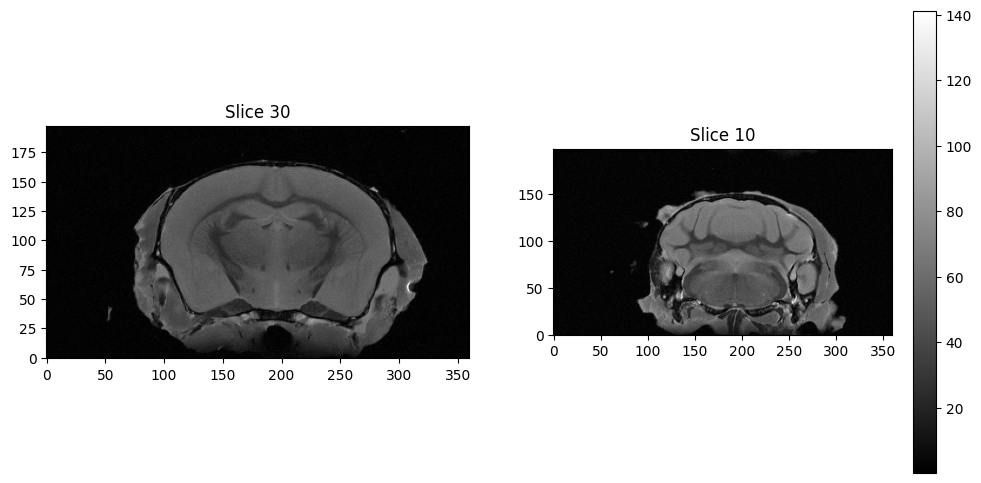

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from dipy.io.image import load_nifti

# Load the NIfTI file
folder_path = "/home/jacob/Documents/CFIN/20250321_DataPack_maskLC/"
t2_file = folder_path + "RWK_ExVivo_InSkull_20048_0L1R_T2_TurboRARE_noCrop_Reorient.nii.gz"
data, affine = load_nifti(t2_file)

# Check the shape
print(f"Image shape: {data.shape}")

# Select slices
mid_slice = data.shape[2] // 2
slice_number = 10

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the middle slice
axes[0].imshow(data[:, :, mid_slice].T, cmap="gray", origin="lower")
axes[0].set_title(f"Slice {mid_slice}")

# Display slice 10
axes[1].imshow(data[:, :, slice_number].T, cmap="gray", origin="lower")
axes[1].set_title(f"Slice {slice_number}")

plt.colorbar(axes[1].imshow(data[:, :, slice_number].T, cmap="gray", origin="lower"), ax=axes[1])
plt.show()


Check if mask:

In [6]:
import numpy as np
from dipy.io.image import load_nifti

# Load the file
folder_path = "/home/jacob/Documents/CFIN/20250321_DataPack_maskLC/"

mask_file = folder_path + "RWK_ExVivo_InSkull_20048_0L1R_T2_TurboRARE_noCrop_Reorient_maskLC_20241104.nii.gz"
data, _ = load_nifti(mask_file)

# Print unique values
unique_values = np.unique(data)
print(f"Unique values in the image: {unique_values}")


Unique values in the image: [0. 1. 2.]


Above seems to be mask, since integer values.

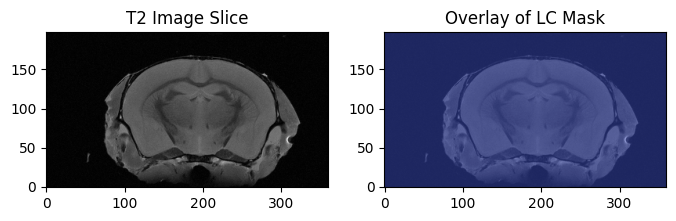

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from dipy.io.image import load_nifti

t2_data, _ = load_nifti(t2_file)
mask_data, _ = load_nifti(mask_file)

# Choose a slice to visualize
slice_idx = t2_data.shape[2] // 2  # Middle slice

# Display T2 image and mask overlay
plt.figure(figsize=(8, 8))

# T2 Image
plt.subplot(1, 2, 1)
plt.imshow(t2_data[:, :, slice_idx].T, cmap='gray', origin='lower')
plt.title("T2 Image Slice")

# Mask Overlay
plt.subplot(1, 2, 2)
plt.imshow(t2_data[:, :, slice_idx].T, cmap='gray', origin='lower')
plt.imshow(mask_data[:, :, slice_idx].T, cmap='coolwarm', alpha=0.5, origin='lower')  # Overlay mask in colors
plt.title("Overlay of LC Mask")

plt.show()


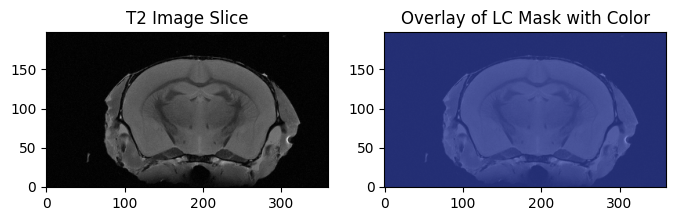

In [ ]:
/home/jacob/Documents/CFIN/20250321_DataPack_MT_LCdetect/20049_0L1R/20250114_LCdetect/00_raw/27_FLASH

t2_data, _ = load_nifti(t2_file)
mask_data, _ = load_nifti(mask_file)

# Choose a slice to visualize
slice_idx = t2_data.shape[2] // 2  # Middle slice

# Create a custom colormap to highlight only the LC regions (1 and 2)
overlay_mask = np.zeros_like(mask_data)
overlay_mask[mask_data == 1] = 1  # Highlight Left LC
overlay_mask[mask_data == 2] = 2  # Highlight Right LC

# Plot the T2 image with the mask overlay
plt.figure(figsize=(8, 8))

# Original T2 Image
plt.subplot(1, 2, 1)
plt.imshow(t2_data[:, :, slice_idx].T, cmap='gray', origin='lower')
plt.title("T2 Image Slice")

# Mask Overlay (with distinct color for LC)
plt.subplot(1, 2, 2)
plt.imshow(t2_data[:, :, slice_idx].T, cmap='gray', origin='lower')

# Add colored mask overlay for LC regions (Left LC = red, Right LC = blue)
plt.imshow(overlay_mask[:, :, slice_idx].T, cmap='coolwarm', alpha=0.6, origin='lower')  
plt.title("Overlay of LC Mask with Color")

plt.show()


Making a gif that travels through the brain in the x and y directions. Storing the gif in the folder.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from dipy.io.image import load_nifti

# Load the NIfTI file
folder_path = "/home/jacob/Documents/CFIN/20250321_DataPack_maskLC/"
t2_file = folder_path + "RWK_ExVivo_InSkull_20048_0L1R_T2_TurboRARE_noCrop_Reorient.nii.gz"
data, affine = load_nifti(t2_file)

# Create a writer for the GIF
gif_filename = "/home/jacob/brain_slices_y.gif"
with imageio.get_writer(gif_filename, mode='I', duration=0.1) as writer:
    for i in range(data.shape[1]):  # Iterate through Y-axis (coronal slices)
        slice_img = data[:, i, :]  # Extract coronal slice

        # Plot the slice
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(np.rot90(slice_img), cmap='gray', origin='lower')  # Fix rotation
        ax.set_axis_off()  

        # Save temporary image to memory
        fig.canvas.draw()
        frame = np.array(fig.canvas.renderer.buffer_rgba())

        # Append frame to GIF
        writer.append_data(frame)
        plt.close(fig)

print(f"GIF created: {gif_filename}")


gif_filename = "/home/jacob/brain_slices_x.gif"
with imageio.get_writer(gif_filename, mode='I', duration=0.1) as writer:
    for i in range(data.shape[0]):  # Loop over X
        slice_img = np.rot90(data[i, :, :])  # Rotate for proper orientation
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(slice_img, cmap='gray', origin='lower')
        ax.set_axis_off()
        tmp_filename = f"/tmp/slice_{i}.png"
        plt.savefig(tmp_filename, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        writer.append_data(imageio.imread(tmp_filename))

print(f"GIF created: {gif_filename}")


GIF created: /home/jacob/brain_slices_y.gif


/tmp/ipykernel_4901/122839862.py:43: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(tmp_filename))


GIF created: /home/jacob/brain_slices_x.gif


Trying and so far failing to make a 3d visualization of the brain.

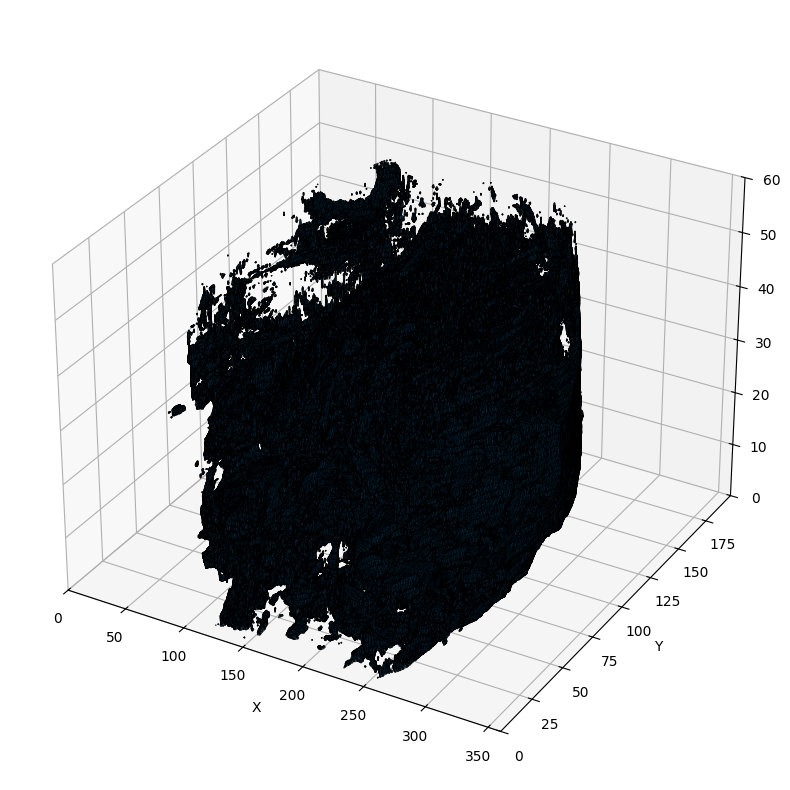

In [19]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Load the NIfTI file
img = nib.load(t2_file)
data = img.get_fdata()

# Choose an isovalue (you might need to experiment)
iso_value = np.percentile(data, 90)  # Adjust this for better contrast

# Apply marching cubes to extract a surface
verts, faces, _, _ = measure.marching_cubes(data, level=iso_value, step_size=1)

# Plot the result
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# Create the mesh
mesh = Poly3DCollection(verts[faces], alpha=0.5, edgecolor="black")
ax.add_collection3d(mesh)

# Set limits and labels
ax.set_xlim(0, data.shape[0])
ax.set_ylim(0, data.shape[1])
ax.set_zlim(0, data.shape[2])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()


A raw brain from the "small" data set folder. It is more grainy than the images above, which I assume have been denoised.

Image shape: (360, 198, 40)


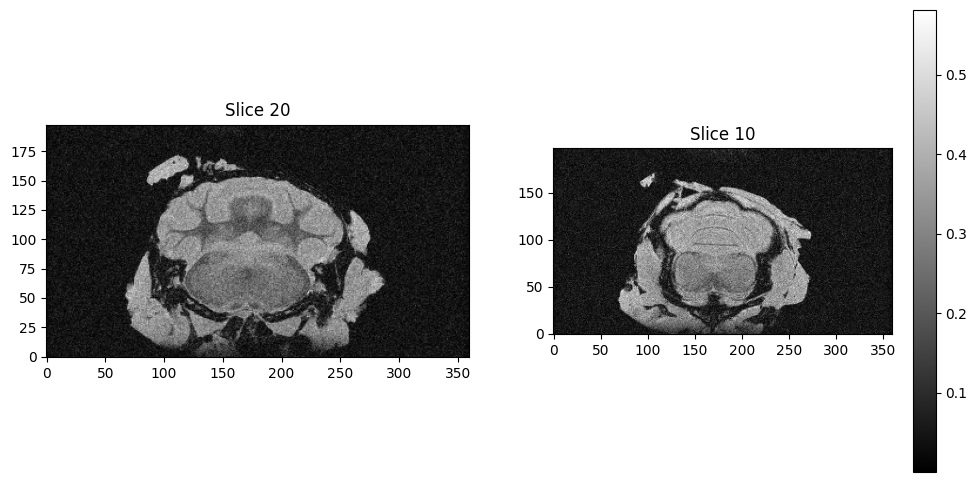

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dipy.io.image import load_nifti

# Load the NIfTI file
folder_path = "/home/jacob/Documents/CFIN/20250321_DataPack_MT_LCdetect/20049_0L1R/20250114_LCdetect/00_raw/27_FLASH/"
t2_file = folder_path + "RWK_ExVivo_InSkull_20049_0L1R_20250114_LCdetect_270001_T1_FLASH_3D.nii"
data, affine = load_nifti(t2_file)

# Check the shape
print(f"Image shape: {data.shape}")

# Select slices
mid_slice = data.shape[2] // 2
slice_number = 10

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the middle slice
axes[0].imshow(data[:, :, mid_slice].T, cmap="gray", origin="lower")
axes[0].set_title(f"Slice {mid_slice}")

# Display slice 10
axes[1].imshow(data[:, :, slice_number].T, cmap="gray", origin="lower")
axes[1].set_title(f"Slice {slice_number}")

plt.colorbar(axes[1].imshow(data[:, :, slice_number].T, cmap="gray", origin="lower"), ax=axes[1])
plt.show()


In [9]:
import nibabel as nib

# Load the NIfTI file
img = nib.load(t2_file)

# Get the shape of the image data
print(f"Image shape: {img.shape}")


Image shape: (360, 198, 60)


Image shape: (150, 100, 25)


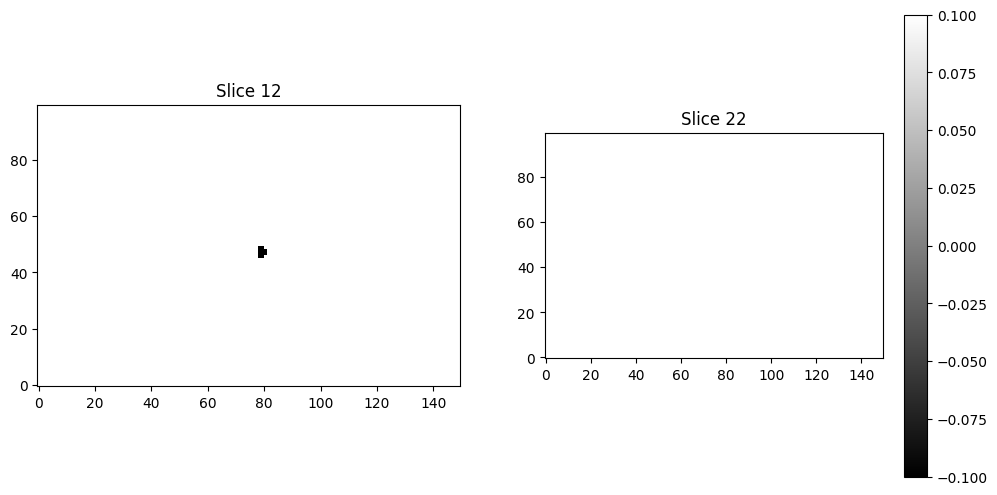

In [16]:
folder_path = "/home/jacob/Documents/CFIN/20250321_DataPack_MT_LCdetect/20049_0L1R/20250114_LCdetect/05_rois/2320001_T1_FLASH_3D_LCmask"

file_name = "RWK_ExVivo_InSkull_20049_0L1R_20250114_LCdetect_2320001_T1_FLASH_3D_LCmask_r01.nii.gz"

file_path = folder_path + "/" + file_name


data, affine = load_nifti(file_path)

# Check the shape
print(f"Image shape: {data.shape}")

# Select slices
mid_slice = data.shape[2] // 2
slice_number = 22

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the middle slice
axes[0].imshow(data[:, :, mid_slice].T, cmap="gray", origin="lower")
axes[0].set_title(f"Slice {mid_slice}")

# Display slice 10
axes[1].imshow(data[:, :, slice_number].T, cmap="gray", origin="lower")
axes[1].set_title(f"Slice {slice_number}")

plt.colorbar(axes[1].imshow(data[:, :, slice_number].T, cmap="gray", origin="lower"), ax=axes[1])
plt.show()


In [44]:
name_of_dki_mat_file = "DKI_RWK_ExVivo_InSkull_20049_0L0R_150001_DKI_full_30dir_150um_ES.mat"
path_to_folder = "/home/jacob/Documents/CFIN/1_maskLC_DKIfit_T2_images"

path_to_file = path_to_folder +"/"  + name_of_dki_mat_file


import scipy.io

# Load the .mat file
mat_file = scipy.io.loadmat(path_to_file)

# Display the contents
print(mat_file)


{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sat Jun 24 02:49:57 2023', '__version__': '1.0', '__globals__': [], 'MD': array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

  

In [24]:
import numpy as np
print(np.isnan(data["MD"]).sum() / data["MD"].size)  # Fraction of NaNs in MD
print(np.isnan(data["MK"]).sum() / data["MK"].size)  # Fraction of NaNs in MK


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [40]:
import os
import numpy as np
import scipy.io
import random

# Define the path to your dataset folder
data_dir = path_to_folder

# Find all .mat files
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]

# Fields to check
fields_to_check = ["MK", "MD", "fitmatrix"]

# Function to check a random element in a matrix
def check_random_element(matrix):
    if isinstance(matrix, np.ndarray) and matrix.size > 0:  # Ensure it's an array with elements
        random_index = tuple(random.randint(0, dim - 1) for dim in matrix.shape)  # Random index
        return matrix[random_index]  # Return the value at the random index
    return None  # Return None if it's not a valid array

# Loop through each file and check the fields
for mat_file in mat_files:
    file_path = os.path.join(data_dir, mat_file)
    mat_data = scipy.io.loadmat(file_path)
    
    all_nan = True  # Assume the file contains only NaNs

    for field in fields_to_check:
        if field in mat_data:
            # print(f"here I print {field}")
            random_value = check_random_element(mat_data[field])
            
            if random_value is not None and not np.isnan(random_value):  # If any value is valid, mark as non-NaN
                all_nan = False
                print(f"In {mat_file} the random_value in {field} is {random_value}")
                
                break  # No need to check further for this file
    
    if all_nan:
        print(f"{mat_file}: Only contains NaNs ❌")
    # else:
    #     print(f"{mat_file}: Contains valid data ✅")


In DKI_RWK_ExVivo_InSkull_22353_2L0R_70001_DKI_full_30dir_150um_ES.mat the random_value in fitmatrix is 9.588266434109764e-08
In DKI_RWK_ExVivo_InSkull_20049_2L0R_50001_DKI_full_30dir_150um_ES.mat the random_value in MK is 0.35103849776678414
In DKI_RWK_ExVivo_InSkull_20048_2L0R_50001_DKI_full_30dir_150um_ES.mat the random_value in MK is 1.1073773608509254
In DKI_RWK_ExVivo_InSkull_22349_1L0R_70001_DKI_full_30dir_150um_ES.mat the random_value in MK is 0.32954102196899915
In DKI_RWK_ExVivo_InSkull_20049_0L0R_150001_DKI_full_30dir_150um_ES.mat the random_value in MD is 0.4195472246396325
DKI_RWK_ExVivo_InSkull_20049_0L2R_50001_DKI_full_30dir_150um_ES.mat: Only contains NaNs ❌
In DKI_RWK_ExVivo_InSkull_22478_0L1R_70001_DKI_full_30dir_150um_ES.mat the random_value in fitmatrix is 1.204850658938991
In DKI_RWK_ExVivo_InSkull_20050_0L0R_90001_DKI_full_30dir_150um_ES.mat the random_value in MK is 1.1579583326293696
In DKI_RWK_ExVivo_InSkull_20050_0L1R_50001_DKI_full_30dir_150um_ES.mat the rand

In [64]:
import numpy as np
import random
import scipy.io
import os

# Define the path to your dataset folder
data_dir = path_to_folder

# Find all .mat files
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]

# Fields to check
fields_to_check = ["MK", "MD", "fitmatrix"]

# Function to check a random element in a matrix and return its index
def check_random_element(matrix):
    if isinstance(matrix, np.ndarray) and matrix.size > 0:  # Ensure it's an array with elements
        random_index = tuple(random.randint(0, dim - 1) for dim in matrix.shape)  # Random index
        value = matrix[random_index]  # Get the value at the random index
        return value, random_index  # Return both the value and the index
    return None, None  # Return None if it's not a valid array

# Loop through each file and check the fields
for mat_file in mat_files:
    file_path = os.path.join(data_dir, mat_file)
    mat_data = scipy.io.loadmat(file_path)
    
    all_nan = True  # Assume the file contains only NaNs

    for field in fields_to_check:
        if field in mat_data:
            # Check a random element in the matrix and get both value and index
            random_value, random_index = check_random_element(mat_data[field])
            
            if random_value is not None and not np.isnan(random_value):  # If any value is valid, mark as non-NaN
                all_nan = False
                print(f"In {mat_file}, the random_value in {field} is {random_value} at index {random_index}")
                
                break  # No need to check further for this file
    
    if all_nan:
        print(f"{mat_file}: Only contains NaNs ❌")
    # else:
    #     print(f"{mat_file}: Contains valid data ✅")


DKI_RWK_ExVivo_InSkull_22353_2L0R_70001_DKI_full_30dir_150um_ES.mat: Only contains NaNs ❌
In DKI_RWK_ExVivo_InSkull_20049_2L0R_50001_DKI_full_30dir_150um_ES.mat, the random_value in MK is 0.5666110174446736 at index (64, 25, 33)
In DKI_RWK_ExVivo_InSkull_20048_2L0R_50001_DKI_full_30dir_150um_ES.mat, the random_value in fitmatrix is 2.755001323048876e-14 at index (63, 33, 30, 7)
In DKI_RWK_ExVivo_InSkull_22349_1L0R_70001_DKI_full_30dir_150um_ES.mat, the random_value in MD is 1.3723895211505175 at index (37, 9, 40)
DKI_RWK_ExVivo_InSkull_20049_0L0R_150001_DKI_full_30dir_150um_ES.mat: Only contains NaNs ❌
DKI_RWK_ExVivo_InSkull_20049_0L2R_50001_DKI_full_30dir_150um_ES.mat: Only contains NaNs ❌
DKI_RWK_ExVivo_InSkull_22478_0L1R_70001_DKI_full_30dir_150um_ES.mat: Only contains NaNs ❌
In DKI_RWK_ExVivo_InSkull_20050_0L0R_90001_DKI_full_30dir_150um_ES.mat, the random_value in MK is 0.3777678978738116 at index (82, 8, 39)
In DKI_RWK_ExVivo_InSkull_20050_0L1R_50001_DKI_full_30dir_150um_ES.mat, 

In [51]:
#tag udgangspunkt i denne fil, som jeg fraoven ved har en stor nonzero værdi i MD...

file_name = "DKI_RWK_ExVivo_InSkull_20049_0L0R_150001_DKI_full_30dir_150um_ES.mat"

# Define the path to your dataset folder
data_dir = path_to_folder
print(data_dir)

whole_path = data_dir + "/" + file_name

mat_data = scipy.io.loadmat(whole_path)

print(mat_data.keys())


/home/jacob/Documents/CFIN/1_maskLC_DKIfit_T2_images
dict_keys(['__header__', '__version__', '__globals__', 'MD', 'MK', 'fitmatrix', 'mask', 'numpixtofit'])


In [ ]:

# Load the .mat file
mat_data = scipy.io.loadmat(whole_path)

# Access the 'fitmatrix' from the dictionary
fitmatrix = mat_data['fitmatrix']

# Print the fitmatrix
print(fitmatrix)

# # If it's too large, print a section of it (e.g., first 10x10 entries)
# print(fitmatrix[:10, :10])  # Adjust the slice as needed


KeyboardInterrupt: 

In [25]:
type(data)
print(data.keys())
print(data.columns)
print(data[:5])  # First 5 rows if it's an array


AttributeError: 'numpy.ndarray' object has no attribute 'keys'

In [26]:
print(data.dtype)
print(data.shape)


float64
(150, 100, 25)
